### Import Required Libraries

In [1]:

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Handle Imbalanced Dataset
from sklearn.utils import resample

## Machine Learning Models
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Support Vector Machine
from sklearn.svm import SVC

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

##Evaluation Metrics
# Accuracy
from sklearn.metrics import accuracy_score

# Precision, Recall, F1-Score
from sklearn.metrics import classification_report

# Confusion Matrix
from sklearn.metrics import confusion_matrix

# Save and Load Models
import joblib

In [3]:

# Load Dataset from Google Drive
# Read CSV file into dataframe
df = pd.read_csv(r"C:\Users\hp\Documents\hsd\fertilizer_recommendation.csv")

## Display Dataset
# Show first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())

## Dataset Information
# Show dataset structure
print("\nDataset Information:")
print(df.info())

# Dataset Shape
# Number of rows and columns
print("\nDataset Shape:")
print(df.shape)



First 5 Rows of Dataset:
  Soil_Type  Soil_pH  Soil_Moisture  Nitrogen_Level  Phosphorus_Level  \
0      Silt     6.39          47.34              59                56   
1      Clay     7.98          19.28             104                53   
2     Sandy     7.61          22.89              56                20   
3     Sandy     7.89          38.27              39                64   
4      Clay     5.16          13.38             105                89   

   Potassium_Level  Temperature  Humidity  Rainfall Crop_Type  \
0               18        24.40     46.27   1030.21     Maize   
1               98        24.17     51.87    714.84    Potato   
2               40        36.52     68.36   2263.05     Maize   
3               22        21.94     62.28   1917.67     Wheat   
4               82        13.64     55.53   1428.78     Maize   

  Recommended_Fertilizer  
0                   Urea  
1                    NPK  
2                   Urea  
3                   Urea  
4         

### Data preprocessing

In [4]:

# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print(df.duplicated())

# Statistical summary
print(df.describe())

Soil_Type                 0
Soil_pH                   0
Soil_Moisture             0
Nitrogen_Level            0
Phosphorus_Level          0
Potassium_Level           0
Temperature               0
Humidity                  0
Rainfall                  0
Crop_Type                 0
Recommended_Fertilizer    0
dtype: int64
0       False
1       False
2       False
3       False
4       False
        ...  
4921    False
4922    False
4923    False
4924    False
4925    False
Length: 4926, dtype: bool
           Soil_pH  Soil_Moisture  Nitrogen_Level  Phosphorus_Level  \
count  4926.000000    4926.000000     4926.000000       4926.000000   
mean      6.469523      35.292576       85.973203         46.711531   
std       1.164221      14.366594       40.901706         23.378610   
min       4.500000      10.010000       20.000000         10.000000   
25%       5.460000      22.970000       50.000000         26.000000   
50%       6.440000      35.420000       84.000000         44.500000   
75

### Explanatory Data Analaysis(EDA)

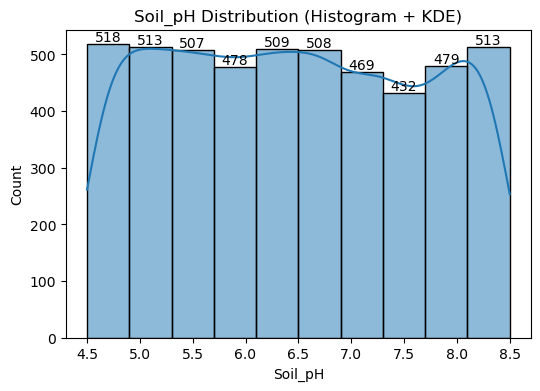

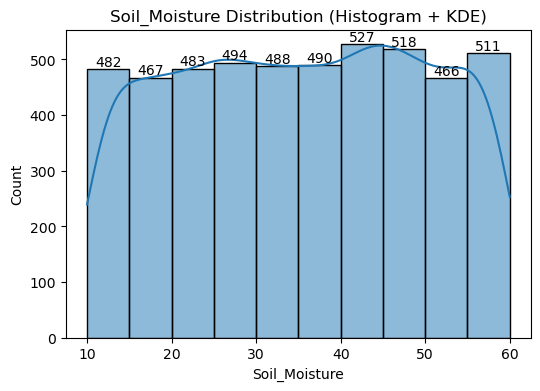

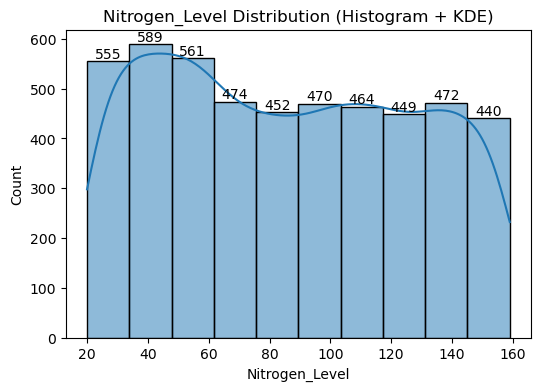

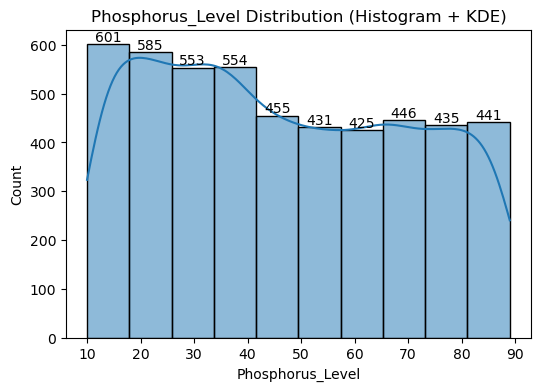

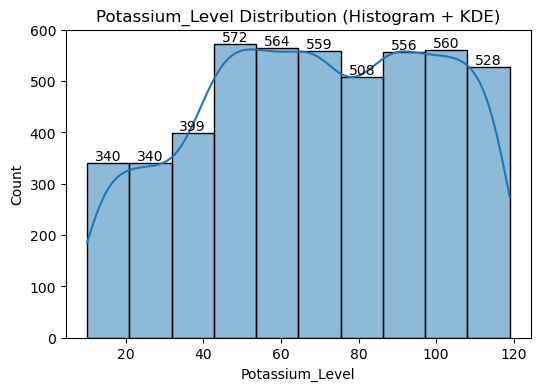

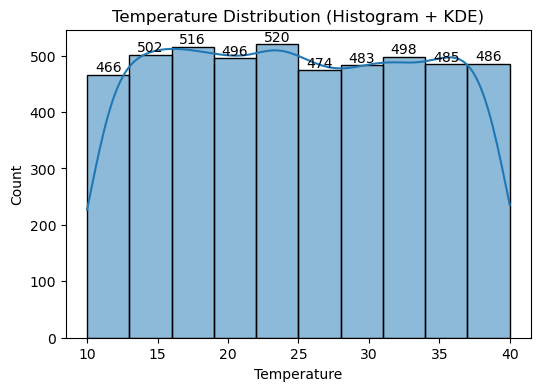

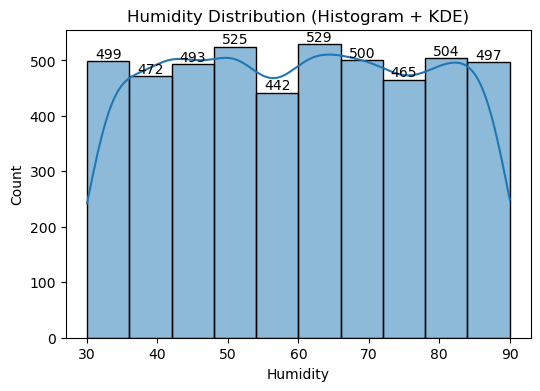

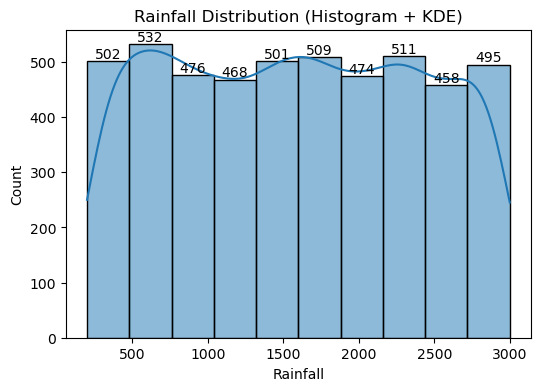

In [5]:

## Plot histograms of features
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Loop through each feature
for col in numeric_df.columns:

    plt.figure(figsize=(6,4))

    # Plot histogram with KDE
    ax = sns.histplot(
        numeric_df[col],
        bins=10,
        kde=True   # add smooth KDE curve
    )

    # Add count values on each bar
    for patch in ax.patches:
        height = patch.get_height()  # number of values in bin

        if height > 0:
            ax.text(
                patch.get_x() + patch.get_width()/2,  
                height,                               
                int(height),                           
                ha='center',
                va='bottom'
            )

    # Titles and labels
    plt.title(f"{col} Distribution (Histogram + KDE)")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.show()



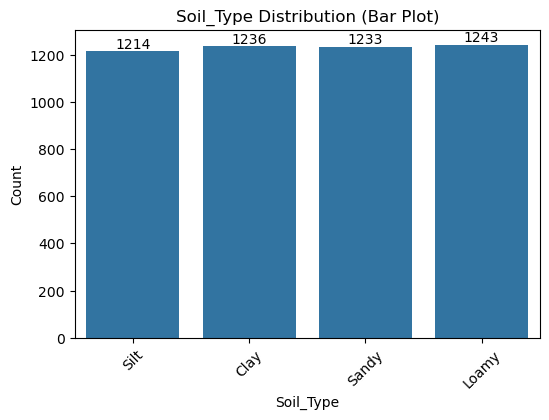

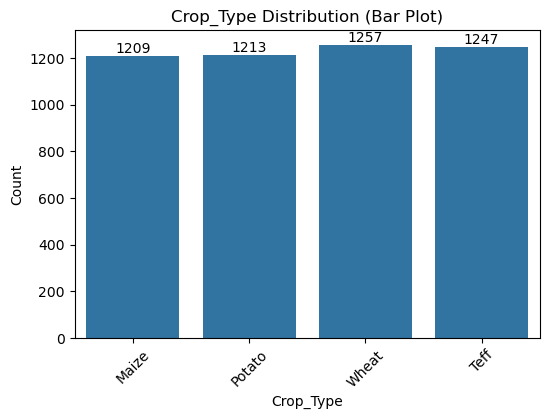

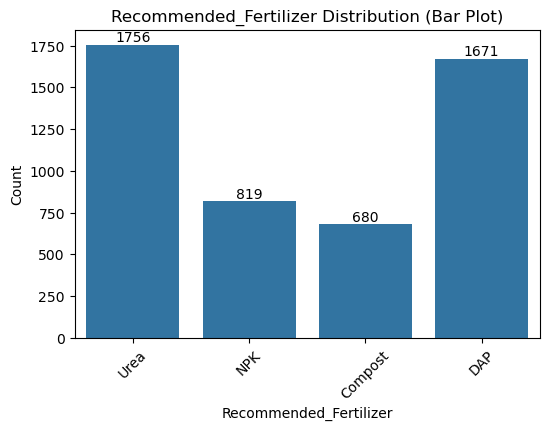

In [6]:

## Plot bar charts of features
import matplotlib.pyplot as plt
import seaborn as sns

# Select only categorical columns
categorical_df = df.select_dtypes(include=['object'])

# Loop through each feature
for col in categorical_df.columns:

    plt.figure(figsize=(6,4))

    # Plot bar chart
    ax = sns.countplot(x=categorical_df[col])

    # Add count values on each bar
    for patch in ax.patches:
        height = patch.get_height()

        if height > 0:
            ax.text(
                patch.get_x() + patch.get_width()/2,  
                height,                               
                int(height),                        
                ha='center',
                va='bottom'
            )

    # Titles and labels
    plt.title(f"{col} Distribution (Bar Plot)")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.show()



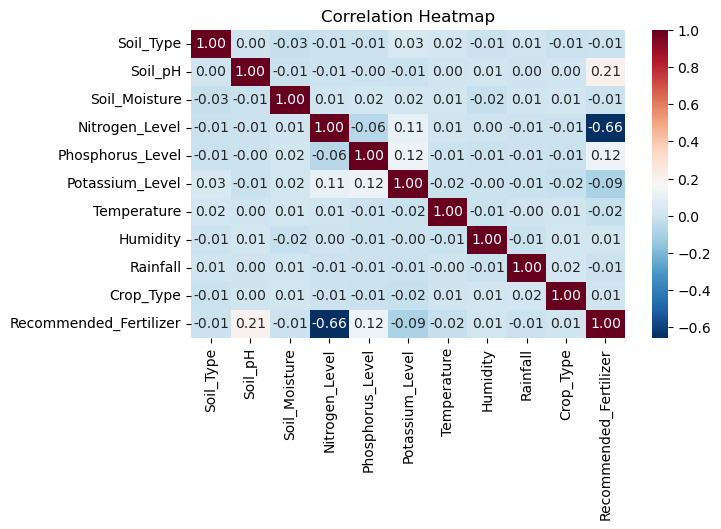

In [47]:
# Correlation Heatmap

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(7, 4))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    fmt=".2f"
)

# Title
plt.title("Correlation Heatmap")

# Show plot
plt.show()

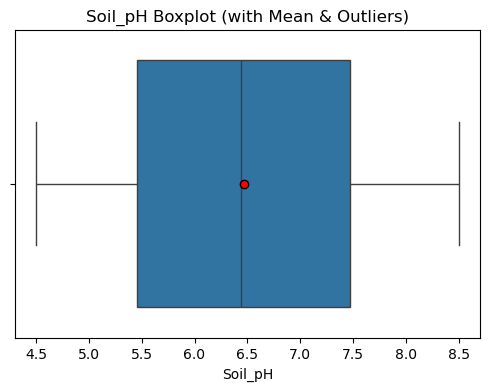

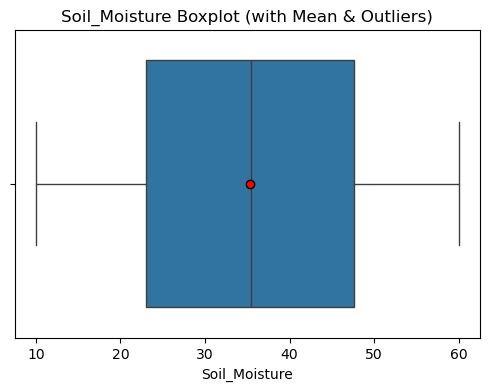

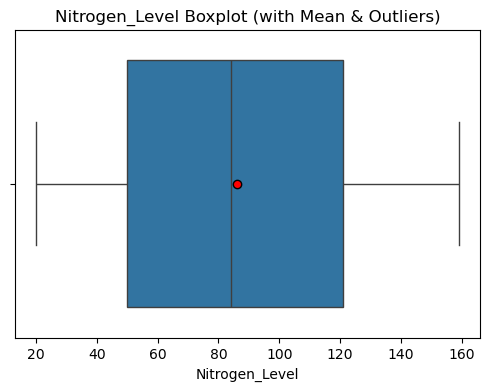

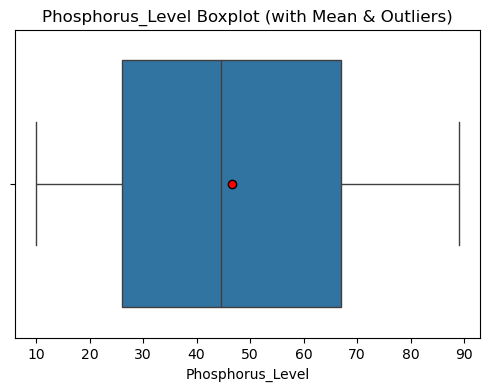

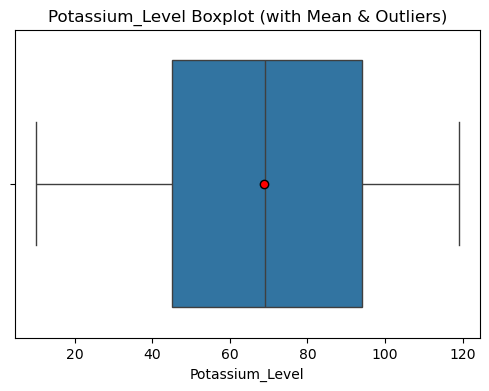

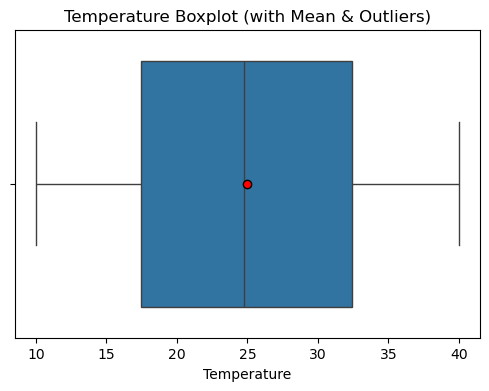

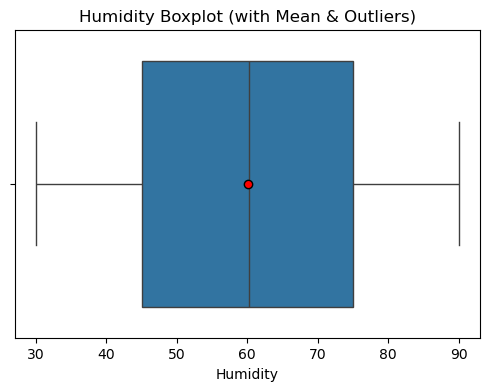

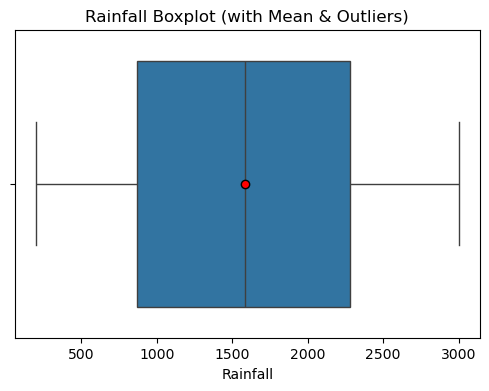

In [18]:

## Boxplots of numeric features
for col in numeric_df.columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=numeric_df[col],
        showmeans=True,  # show mean point
        meanprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "black"
        }
    )

    plt.title(f"{col} Boxplot (with Mean & Outliers)")
    plt.xlabel(col)

    plt.show()

In [8]:

# Create encoders
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fert = LabelEncoder()
# Convert text → numbers
df['Soil_Type'] = le_soil.fit_transform(df['Soil_Type'])
df['Crop_Type'] = le_crop.fit_transform(df['Crop_Type'])
df['Recommended_Fertilizer'] = le_fert.fit_transform(
    df['Recommended_Fertilizer'])

In [9]:
print(le_fert.classes_)

['Compost' 'DAP' 'NPK' 'Urea']


In [10]:
mapping = dict(
    zip(le_fert.classes_,
        le_fert.transform(le_fert.classes_))
)

print(mapping)

{'Compost': np.int64(0), 'DAP': np.int64(1), 'NPK': np.int64(2), 'Urea': np.int64(3)}


In [11]:
print(le_soil.classes_)

['Clay' 'Loamy' 'Sandy' 'Silt']


In [12]:
mapping = dict(
    zip(le_soil.classes_,
        le_soil.transform(le_soil.classes_))
)

print(mapping)

{'Clay': np.int64(0), 'Loamy': np.int64(1), 'Sandy': np.int64(2), 'Silt': np.int64(3)}


## Separate Features and Target

In [13]:

# Separate Features and Target

# Features
X = df[['Soil_Type', 'Soil_pH', 'Soil_Moisture',
        'Nitrogen_Level', 'Phosphorus_Level',
        'Potassium_Level', 'Temperature',
        'Humidity', 'Rainfall', 'Crop_Type']]

# Target variable
y = df['Recommended_Fertilizer']

# Show feature columns
print("Features:", X.columns)

Features: Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Nitrogen_Level',
       'Phosphorus_Level', 'Potassium_Level', 'Temperature', 'Humidity',
       'Rainfall', 'Crop_Type'],
      dtype='object')


#### Check Class Imbalance

In [14]:

# Check Class Imbalance
# Count samples in each class
print(y.value_counts())

# Show percentage distribution
print("\nClass Percentage:")

print(
    y.value_counts(normalize=True) * 100
)

Recommended_Fertilizer
3    1756
1    1671
2     819
0     680
Name: count, dtype: int64

Class Percentage:
Recommended_Fertilizer
3    35.647584
1    33.922046
2    16.626066
0    13.804304
Name: proportion, dtype: float64


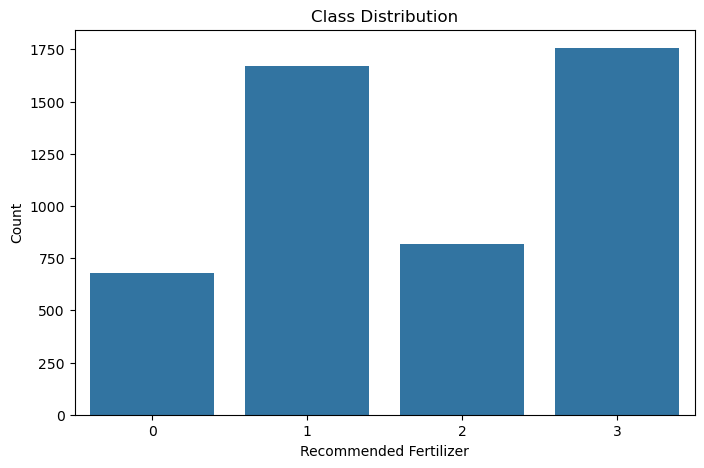

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x=y)

plt.title("Class Distribution")

plt.xlabel("Recommended Fertilizer")

plt.ylabel("Count")

plt.show()

## Train-Test Split

In [17]:

# Train-Test Split
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      
    random_state=42,
    stratify=y
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (3940, 10)
X_test shape : (986, 10)
y_train shape: (3940,)
y_test shape : (986,)


## Feature Scaling

In [18]:

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

# Display shapes
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (3940, 10)
X_test_scaled shape : (986, 10)


#### Apply SMOTE

In [20]:

 from imblearn.over_sampling import SMOTE
import pandas as pd

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE on training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)
# Check class distribution
print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Recommended_Fertilizer
3    1404
1    1337
2     655
0     544
Name: count, dtype: int64

After SMOTE:
Recommended_Fertilizer
2    1404
1    1404
3    1404
0    1404
Name: count, dtype: int64


## Train MachineLearning Models

In [21]:
# Train Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=2,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
    
)

# Train using original training data
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=2,
                       min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

In [22]:

# Train SVM Model
from sklearn.svm import SVC

# Create model
svm_model = SVC(
    C=0.01,
    kernel='linear'
)

# Train model using scaled data
svm_model.fit(X_train_scaled, y_train)

SVC(C=0.01, kernel='linear')

In [23]:

# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

# Train using original training data
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=4,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=50, random_state=42)

In [24]:

# Improved XGBoost Model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=10,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=10, n_jobs=None,
              num_parallel_tree=None, ...)

## Evalute the models

Model: Decision Tree
Test Accuracy: 0.8093306288032455
              precision    recall  f1-score   support

     Compost       0.00      0.00      0.00       136
         DAP       1.00      0.93      0.97       334
         NPK       0.47      1.00      0.64       164
        Urea       1.00      0.91      0.96       352

    accuracy                           0.81       986
   macro avg       0.62      0.71      0.64       986
weighted avg       0.77      0.81      0.77       986



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



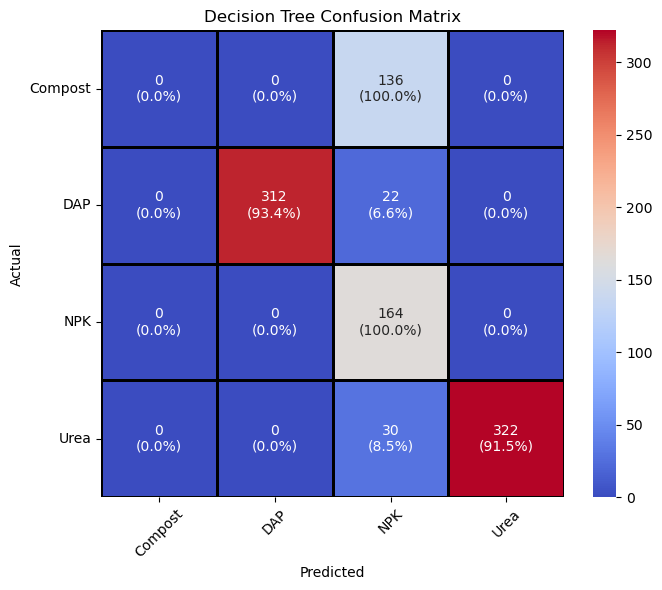

In [25]:

# Decision Tree Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Predict on test data
y_pred = dt_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Model: Decision Tree")

print("Test Accuracy:", acc)

# Get correct class names

class_names = le_fert.inverse_transform(
    np.unique(y_test)
)

# Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

# Convert confusion matrix into percentage
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create labels
labels = np.array([
    [
        f"{cm[i, j]}\n({cm_percent[i, j]*100:.1f}%)"
        for j in range(cm.shape[1])
    ]
    for i in range(cm.shape[0])
])

# Plot heatmap
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='coolwarm',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor='black'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

Model: SVM
Test Accuracy: 0.8133874239350912
              precision    recall  f1-score   support

     Compost       0.67      0.53      0.59       136
         DAP       0.89      0.91      0.90       334
         NPK       0.72      0.60      0.66       164
        Urea       0.81      0.93      0.87       352

    accuracy                           0.81       986
   macro avg       0.78      0.74      0.75       986
weighted avg       0.81      0.81      0.81       986



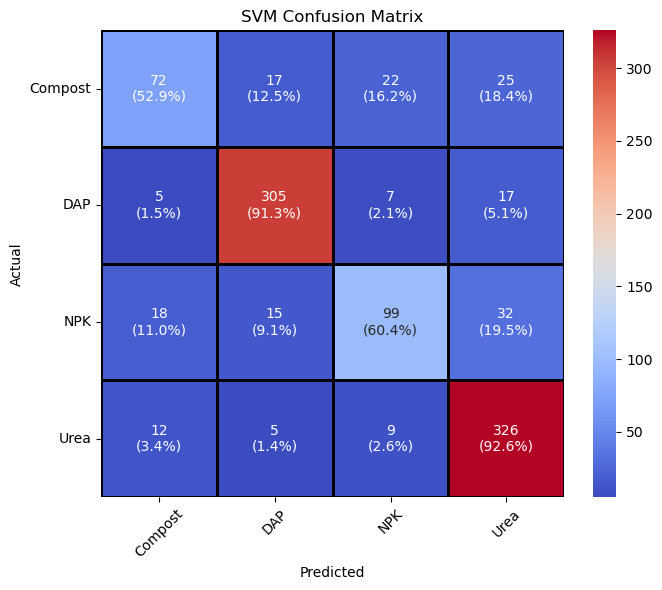

In [26]:

# SVM Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Predict on test data
y_pred = svm_model.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)



print("Model: SVM")

print("Test Accuracy:", acc)

# Get correct class names
class_names = le_fert.inverse_transform(
    np.unique(y_test)
)

# Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Convert confusion matrix into percentage
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create labels
labels = np.array([
    [
        f"{cm[i, j]}\n({cm_percent[i, j]*100:.1f}%)"
        for j in range(cm.shape[1])
    ]
    for i in range(cm.shape[0])
])

# Plot heatmap
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='coolwarm',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor='black'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

Model: Random Forest
Test Accuracy: 0.9006085192697769
              precision    recall  f1-score   support

     Compost       0.99      0.66      0.79       136
         DAP       1.00      0.93      0.97       334
         NPK       0.63      1.00      0.77       164
        Urea       1.00      0.91      0.96       352

    accuracy                           0.90       986
   macro avg       0.90      0.88      0.87       986
weighted avg       0.94      0.90      0.91       986



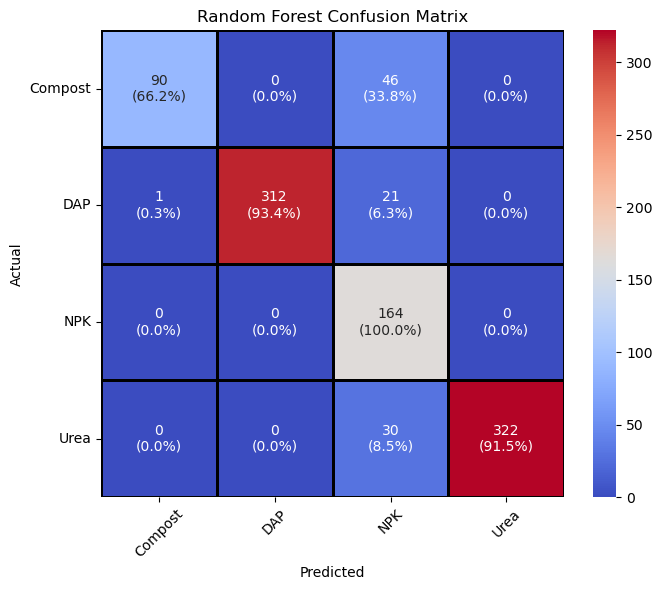

In [27]:

# Random Forest Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Predict on test data
y_pred = rf_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Model: Random Forest")

print("Test Accuracy:", acc)

# Get correct class names
class_names = le_fert.inverse_transform(
    np.unique(y_test)
)

# Classification Report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

# Convert confusion matrix into percentage
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create labels
labels = np.array([
    [
        f"{cm[i, j]}\n({cm_percent[i, j]*100:.1f}%)"
        for j in range(cm.shape[1])
    ]
    for i in range(cm.shape[0])
])

# Plot Heatmap

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='coolwarm',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor='black'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

Model: XGBoost
Test Accuracy: 0.8306288032454361
              precision    recall  f1-score   support

     Compost       0.99      0.66      0.79       136
         DAP       1.00      0.93      0.96       334
         NPK       1.00      0.40      0.57       164
        Urea       0.68      1.00      0.81       352

    accuracy                           0.83       986
   macro avg       0.92      0.75      0.78       986
weighted avg       0.88      0.83      0.82       986



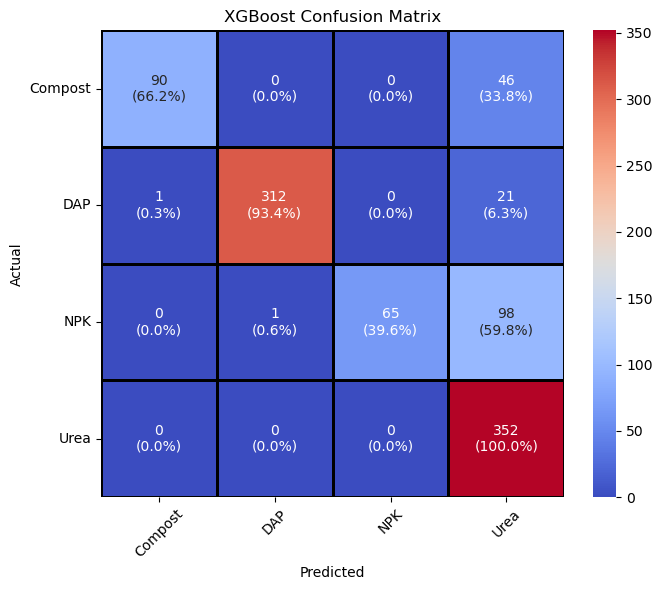

In [28]:

# XGBoost Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Predict on test data
y_pred = xgb_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

print("Model: XGBoost")

print("Test Accuracy:", acc)

# Get correct class names
class_names = le_fert.inverse_transform(
    np.unique(y_test)
)

# Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

# Convert confusion matrix into percentage
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create labels
labels = np.array([
    [
        f"{cm[i, j]}\n({cm_percent[i, j]*100:.1f}%)"
        for j in range(cm.shape[1])
    ]
    for i in range(cm.shape[0])
])

# Plot Heatmap

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=labels,
    fmt='',
    cmap='coolwarm',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor='black'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Train Test accuracy

In [29]:

# Decision Tree Train & Test Accuracy

from sklearn.metrics import accuracy_score

# Training Accuracy
train_pred = dt_model.predict(X_train)

train_acc = accuracy_score(
    y_train,
    train_pred
)

print("Training Accuracy:", train_acc)

# Testing Accuracy
test_pred = dt_model.predict(X_test)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print("Testing Accuracy:", test_acc)

Training Accuracy: 0.816751269035533
Testing Accuracy: 0.8093306288032455


In [30]:

# SVM Train & Test Accuracy

from sklearn.metrics import accuracy_score

# Training Accuracy
train_pred = svm_model.predict(X_train_scaled)

train_acc = accuracy_score(
    y_train,
    train_pred
)

print("Training Accuracy:", train_acc)

# Testing Accuracy

test_pred = svm_model.predict(X_test_scaled)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8266497461928934
Testing Accuracy: 0.8133874239350912


In [31]:

# Random Forest Train & Test Accuracy
from sklearn.metrics import accuracy_score

# Training Accuracy
train_pred = rf_model.predict(X_train)

train_acc = accuracy_score(
    y_train,
    train_pred
)

print("Training Accuracy:", train_acc)

# Testing Accuracy
test_pred = rf_model.predict(X_test)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9121827411167512
Testing Accuracy: 0.9006085192697769


In [32]:

# XGBoost Train & Test Accuracy
from sklearn.metrics import accuracy_score

# Training Accuracy
train_pred = xgb_model.predict(X_train)

train_acc = accuracy_score(
    y_train,
    train_pred
)

print("Training Accuracy:", train_acc)

# Testing Accuracy
test_pred = xgb_model.predict(X_test)

test_acc = accuracy_score(
    y_test,
    test_pred
)

print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8393401015228427
Testing Accuracy: 0.8306288032454361


### Train_test acccuracy graph

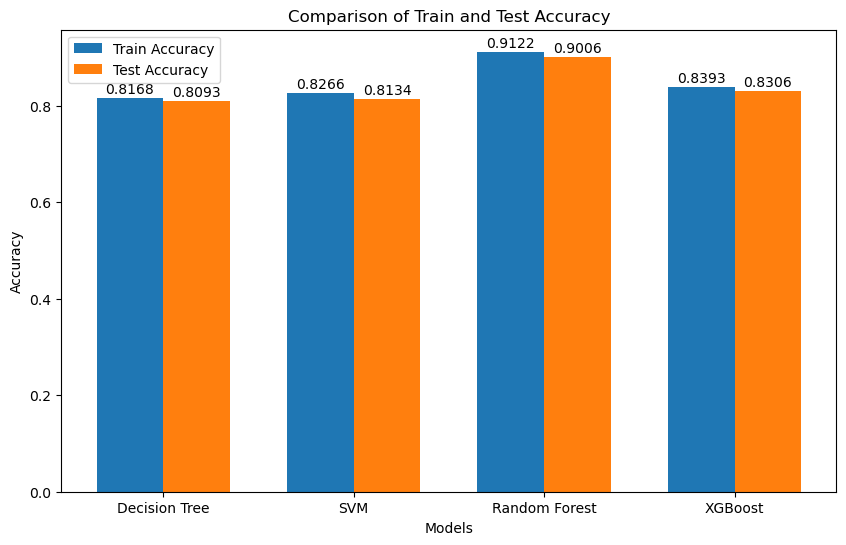

In [33]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score


# Decision Tree Accuracy
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

# SVM Accuracy
svm_train_pred = svm_model.predict(X_train_scaled)
svm_test_pred = svm_model.predict(X_test_scaled)

svm_train_acc = accuracy_score(y_train, svm_train_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)

# Random Forest Accuracy
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

# XGBoost Accuracy
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

xgb_train_acc = accuracy_score(y_train, xgb_train_pred)
xgb_test_acc = accuracy_score(y_test, xgb_test_pred)

# Model Names
models = [
    'Decision Tree',
    'SVM',
    'Random Forest',
    'XGBoost'
]
# Accuracy Lists
train_accuracies = [
    dt_train_acc,
    svm_train_acc,
    rf_train_acc,
    xgb_train_acc
]

test_accuracies = [
    dt_test_acc,
    svm_test_acc,
    rf_test_acc,
    xgb_test_acc
]
# Graph 
x = np.arange(len(models))
width = 0.35
plt.figure(figsize=(10,6))

# Train Accuracy Bars
plt.bar(
    x - width/2,
    train_accuracies,
    width,
    label='Train Accuracy'
)

# Test Accuracy Bars
plt.bar(
    x + width/2,
    test_accuracies,
    width,
    label='Test Accuracy'
)

# Labels and Title
plt.xlabel('Models')

plt.ylabel('Accuracy')

plt.title('Comparison of Train and Test Accuracy')

plt.xticks(x, models)

# Show Accuracy Value
for i, v in enumerate(train_accuracies):
    plt.text(
        i - width/2,
        v + 0.01,
        f"{v:.4f}",
        ha='center'
    )

for i, v in enumerate(test_accuracies):
    plt.text(
        i + width/2,
        v + 0.01,
        f"{v:.4f}",
        ha='center'
    )
# Legend and Display
plt.legend()

plt.show()

## model comparisions

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



MODEL PERFORMANCE TABLE
           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.809331   0.773234  0.809331  0.774042
1            SVM  0.813387   0.806055  0.813387  0.806344
2  Random Forest  0.900609   0.936669  0.900609  0.906053
3        XGBoost  0.830629   0.883467  0.830629  0.819709
BEST MODEL
Model Name : Random Forest
Accuracy   : 0.900609
Precision  : 0.936669
Recall     : 0.900609
F1 Score   : 0.906053


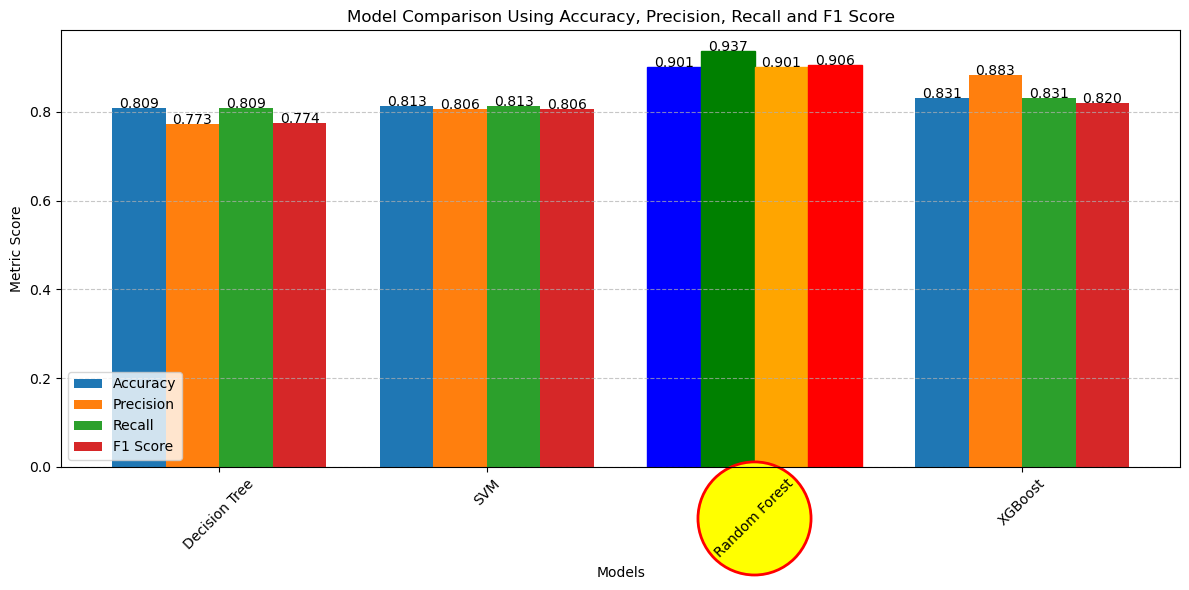

In [34]:

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as npA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
# Create dictionary of models
models = {

    'Decision Tree': dt_model,

    'SVM': svm_model,

    'Random Forest': rf_model,

    'XGBoost': xgb_model
}
# Create empty lists
model_names = []

accuracy_list = []

precision_list = []

recall_list = []

f1_list = []

# Evaluate all models
for name, model in models.items():

    # Prediction section

    if name == 'SVM':

        y_pred = model.predict(X_test_scaled)

    else:

        y_pred = model.predict(X_test)
        
    # Calculate metrics
    acc = accuracy_score(
        y_test,
        y_pred
    )
    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )
    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )
    
    # Store results
   
    model_names.append(name)

    accuracy_list.append(acc)

    precision_list.append(precision)

    recall_list.append(recall)

    f1_list.append(f1)

# Create DataFrame

metrics_df = pd.DataFrame({

    'Model': model_names,

    'Accuracy': accuracy_list,

    'Precision': precision_list,

    'Recall': recall_list,

    'F1 Score': f1_list
})

# Display metrics table
print("MODEL PERFORMANCE TABLE")
print(metrics_df)

# Find best model 
best_index = metrics_df['F1 Score'].idxmax()

best_model_name = metrics_df.loc[
    best_index,
    'Model'
]

best_accuracy = metrics_df.loc[
    best_index,
    'Accuracy'
]

best_precision = metrics_df.loc[
    best_index,
    'Precision'
]

best_recall = metrics_df.loc[
    best_index,
    'Recall'
]

best_f1 = metrics_df.loc[
    best_index,
    'F1 Score'
]
# Print best model information
print("BEST MODEL")
print(f"Model Name : {best_model_name}")

print(f"Accuracy   : {best_accuracy:.6f}")

print(f"Precision  : {best_precision:.6f}")

print(f"Recall     : {best_recall:.6f}")

print(f"F1 Score   : {best_f1:.6f}")

# Create graph
x = np.arange(len(model_names))

width = 0.2

plt.figure(figsize=(12,6))

# Accuracy bars
bars1 = plt.bar(
    x - 1.5*width,
    accuracy_list,
    width,
    label='Accuracy'
)

# Precision bars
bars2 = plt.bar(
    x - 0.5*width,
    precision_list,
    width,

    label='Precision'
)

# Recall bars
bars3 = plt.bar(
    x + 0.5*width,
    recall_list,
    width,
    label='Recall'
)

# F1 Score bars
bars4 = plt.bar(
    x + 1.5*width,
    f1_list,
    width,
    label='F1 Score'
)

# Highlight best model bars
best_pos = model_names.index(best_model_name)

bars1[best_pos].set_color('blue')

bars2[best_pos].set_color('green')

bars3[best_pos].set_color('orange')

bars4[best_pos].set_color('red')

# Add values above bars

for i, v in enumerate(accuracy_list):

    plt.text(
        x[i] - 1.5*width,
        v,
        f"{v:.3f}",
        ha='center'
    )

for i, v in enumerate(precision_list):

    plt.text(
        x[i] - 0.5*width,
        v,
        f"{v:.3f}",
        ha='center'
    )

for i, v in enumerate(recall_list):

    plt.text(
        x[i] + 0.5*width,
        v,
        f"{v:.3f}",
        ha='center'
    )

for i, v in enumerate(f1_list):

    plt.text(
        x[i] + 1.5*width,
        v,
        f"{v:.3f}",
        ha='center'
    )

# Add titles and labels

plt.title(
    "Model Comparison Using Accuracy, Precision, Recall and F1 Score"
)

plt.xlabel("Models")

plt.ylabel("Metric Score")

# Add model names

plt.xticks(
    x,
    model_names,
    rotation=45
)
# Circle Best Model Name
plt.gca().get_xticklabels()[best_pos].set_bbox(

    dict(
        facecolor='yellow',
        edgecolor='red',
        boxstyle='circle',
        linewidth=2
    )
)

# Show legend
plt.legend()

# Add grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)
# Adjust layout
plt.tight_layout()

# Show graph
plt.show()

## Feature importance

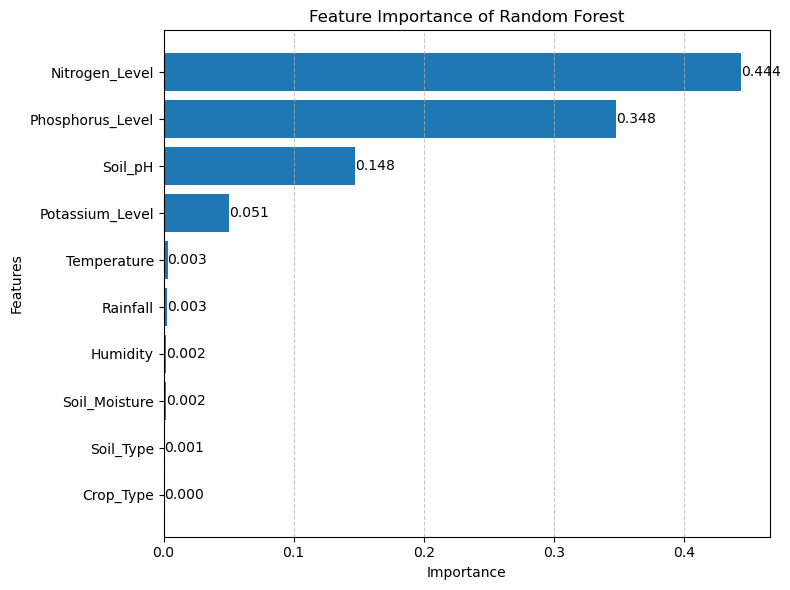

In [35]:
# Feature Importance of Best Model
import matplotlib.pyplot as plt
import numpy as np

# Get best model
best_model = models[best_model_name]

# Check model supports feature importance
#if best_model_name != 'SVM':

# Get importance values from model
importances = best_model.feature_importances_

# Get feature names
feature_names = X.columns

# Sort features
indices = np.argsort(importances)

# Create plot
plt.figure(figsize=(8,6))

bars = plt.barh(

    range(len(indices)),

    importances[indices]
)

# Highlight most important feature

#bars[-1].set_color('red')

# Add feature names
plt.yticks(

    range(len(indices)),

    feature_names[indices]
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title(
    f"Feature Importance of {best_model_name}"
)

# Add values on bars
for i, v in enumerate(importances[indices]):

    plt.text(
        v,
        i,
        f"{v:.3f}",
        va='center'
    )

# Add grid
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.7
)

# Adjust layout
plt.tight_layout()

# Show graph
plt.show()

#else:

#    print("SVM does not support feature importance.")

## Predictions

In [36]:

# PREDICTION FUNCTION

def predict_fertilizer(

    soil_type,
    soil_pH,
    soil_moisture,
    nitrogen,
    phosphorus,
    potassium,
    temperature,
    humidity,
    rainfall,
    crop_type

):

    try:

        # ENCODE INPUTS

        soil_type_encoded = le_soil.transform(
            [soil_type]
        )[0]

        crop_type_encoded = le_crop.transform(
            [crop_type]
        )[0]

        # CREATE DATAFRAME
    
        input_df = pd.DataFrame([{

            'Soil_Type': soil_type_encoded,
            'Soil_pH': soil_pH,
            'Soil_Moisture': soil_moisture,
            'Nitrogen_Level': nitrogen,
            'Phosphorus_Level': phosphorus,
            'Potassium_Level': potassium,
            'Temperature': temperature,
            'Humidity': humidity,
            'Rainfall': rainfall,
            'Crop_Type': crop_type_encoded

        }])

        # PREDICTION

        if best_model_name == 'SVM':

            input_scaled = scaler.transform(
                input_df
            )

            pred = best_model.predict(
                input_scaled
            )

        else:

            pred = best_model.predict(
                input_df
            )

        # DECODE OUTPUT

        fertilizer = le_fert.inverse_transform(
            pred.astype(int)
        )[0]

        return fertilizer

    except Exception as e:

        return f"Error : {str(e)}"

In [41]:

# TEST PREDICTION

prediction = predict_fertilizer(

    soil_type='Clay',
    soil_pH=6.5,
    soil_moisture=45,
    nitrogen=200,
    phosphorus=115,
    potassium=111,
    temperature=28.7,
    humidity=65,
    rainfall=1500,
    crop_type='Wheat'

)

print(
    "Recommended Fertilizer :",
    prediction
)

Recommended Fertilizer : NPK


## Save the model

In [42]:

# SAVE MODEL AND ENCODERS
import joblib

# Save Random Forest model
joblib.dump(
    rf_model,
    "best_model.pkl"
)

# Save fertilizer encoder
joblib.dump(
    le_fert,
    "encoder.pkl"
)

# Save soil encoder
joblib.dump(
    le_soil,
    "encoder_soil.pkl"
)

# Save crop encoder
joblib.dump(
    le_crop,
    "encoder_crop.pkl"
)

print("✅ Model and encoders saved successfully.")

✅ Model and encoders saved successfully.


## DEPLOYMENT

In [43]:
import streamlit as st
import joblib
import pandas as pd

# LOAD MODEL AND ENCODERS
model = joblib.load(
    "best_model.pkl"
)

le_fert = joblib.load(
    "encoder.pkl"
)

le_soil = joblib.load(
    "encoder_soil.pkl"
)

le_crop = joblib.load(
    "encoder_crop.pkl"
)
